In [1]:
import geopandas as gpd
from shapely.geometry import Polygon
import folium
import matplotlib.pyplot as plt

In [7]:
usage_mapping = {
    1000: "Wohngebäude",
    1020: "Nichtwohngebäude",
    2320: "Öffentliche Gebäude",
    2222: "Sonstige",
}

usage_mapping = {
    1000: "Wohngebäude",
    1020: "Wohngemeine",
    2320: "Gebäude für Gewerbe und Industrie mit Wohnen",
}

usage_mapping = {
    1010: "Wohnhaus",
    1100: "Gemischt genutztes Gebäude mit Wohnen",
    1120: "Wohngebäude mit Handel und Dienstleistungen",
    2010: "Gebäude für Handel und Dienstleistungen",
    2020: "Bürogebäude",
    2050: "Geschäftsgebäude",
    2120: "Werkstatt",
    2140: "Gebäude für Vorratshaltung",
    2310: "Gebäude für Handel und Dienstleistung mit Wohnen",
    2463: "Garage",
    2465: "Tiefgarage",
}

default_bbox = [[10.045725448115505, 53.56373965563346],
               [10.04483158296414, 53.56928571310496],
               [10.061462179332965, 53.574146646448916],
               [10.064284911389908, 53.56640800076195]]

default_bbox = [[10.071450882096563, 53.57343719771864],
               [10.078282200812708, 53.57582089436743],
               [10.086978353249249, 53.57780085497406],
               [10.088500780178016, 53.57786434031859],
               [10.08968943613927, 53.57528776626812],
               [10.090770539267197, 53.57544358156409],
               [10.09161951641922, 53.57351782519276],
               [10.081990170144394, 53.57132713390438],
                [10.07602700765947, 53.571645156140086],
                [10.07573490367003, 53.5721943741919],
                [10.072668065541466, 53.57226654319956]]

def_poly = Polygon(default_bbox)
def_poly_gdf = gpd.GeoDataFrame(geometry=[def_poly], crs="EPSG:4326")
buildings_gdf = gpd.read_parquet("buildings.parquet")
buildings_gdf = buildings_gdf.to_crs("EPSG:4326")

In [8]:
def limit_gdf(base_gdf: gpd.GeoDataFrame, limiting_gdf: gpd.GeoDataFrame):
    limiting_geom = limiting_gdf.geometry.iloc[0]

    limited_gdf = base_gdf[base_gdf.geometry.intersects(limiting_geom)].copy()
    #limited_gdf = limited_gdf.reset_index(drop=True)
    
    print("Shape of limited gdf: ", limited_gdf.shape)
    #print(filtered_buildings_gdf.head())
    return limited_gdf

def plot_with_border(base_gdf: gpd.GeoDataFrame, border_gdf: gpd.GeoDataFrame):
    ax = base_gdf.plot(figsize=(10, 10), edgecolor="black", facecolor="none")
    border_gdf.boundary.plot(ax=ax, color="red")

def plot_wit_data(base_gdf: gpd.GeoDataFrame, border_gdf: gpd.GeoDataFrame) -> None:
    base_gdf["usage"] = (base_gdf["gebaeudefunktion"].map(usage_mapping).fillna("Sonstige"))
    
    fig, ax = plt.subplots(figsize=(12, 12))

    base_gdf.plot(
        column="usage",
        legend=True,
        categorical=True,
        ax=ax
    )
    
    border_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=2
    )

    plt.title("Gebäudenutzung")
    plt.show()

def plot_construction_year_histogram(base_gdf: gpd.GeoDataFrame) -> None: 
    years = base_gdf["baujahr"].dropna()
    
    plt.figure(figsize=(12,6))
    plt.hist(years, bins=30)
    plt.xlabel("Baujahr")
    plt.ylabel("Gebäudeanzahl")
    plt.title("Baujahrverteilung")
    plt.show()

Shape of limited gdf:  (374, 25)


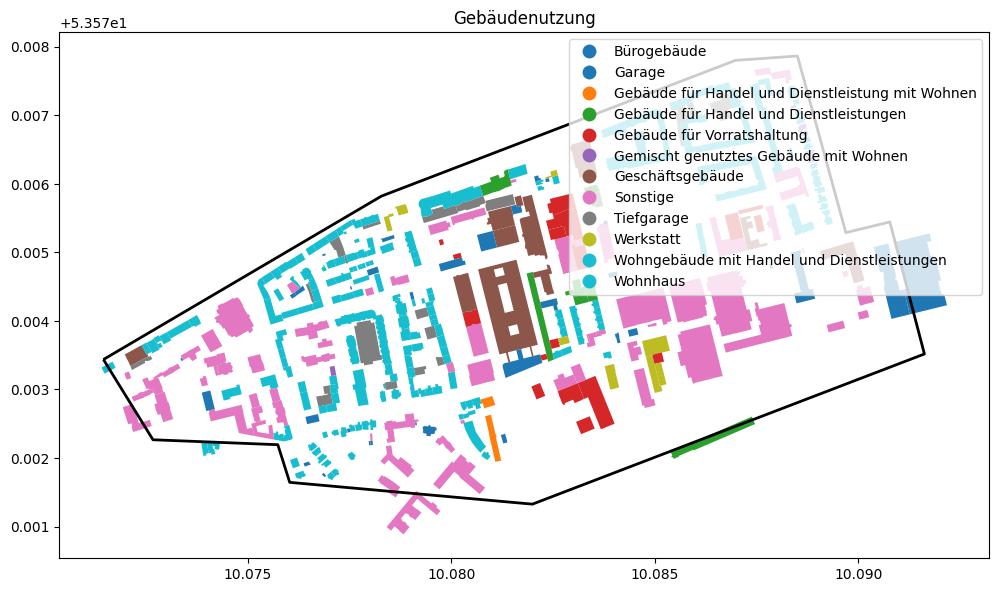

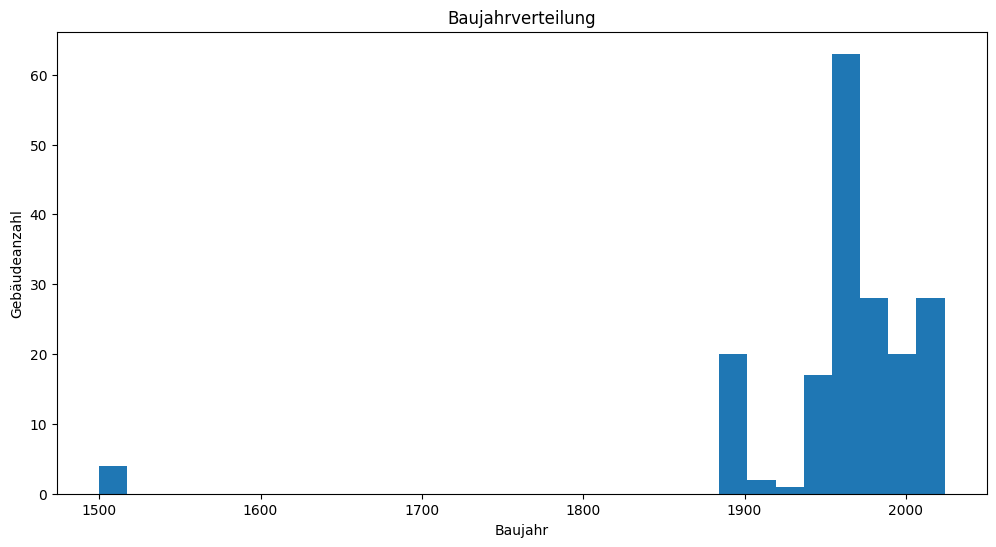

In [9]:
limited_gdf = limit_gdf(buildings_gdf, def_poly_gdf)
plot_wit_data(limited_gdf, def_poly_gdf)
plot_construction_year_histogram(limited_gdf)
#plot_with_border(limited_gdf, def_poly_gdf)

In [5]:
#print(limited_gdf.head())
limited_gdf["gebaeudefunktion"].value_counts()
limited_gdf["gebaeudefunktion"].unique()

array([2050, 2080, 3080, 3091, 1010, 2410, 1120, 3021, 3041, 2465, 3050,
       2020, 2463, 2120, 2140, 2310, 3046, 2110, 2010, 2461, 3211, 2520,
       1130, 2320, 3015, 1020, 1100, 3036, 3072, 2580, 2112, 3034, 3075,
       3040, 3212, 2460, 3060, 1313])

In [6]:
m = folium.Map(location=[53.57, 10.05], zoom_start=15, tiles="CartoDB positron")
for _, row in def_poly_gdf.iterrows():
        folium.GeoJson(row["geometry"]).add_to(m)
for _, row in limited_gdf.iterrows():
        folium.GeoJson(row["geometry"], style_function=lambda x: {"fillColor": "orange"}).add_to(m)
m